<!-- [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VectorInstitute/interpretability/blob/main/implementations/Post-hoc/SHAP/shap-nn-jupyter.ipynb)
 -->
# SHAP for Neural Network Models

## **1. Introduction**

SHAP is model-agnostic and can be used to explain other black box models as well, for example, neural networks.
The shap module in python has something called KernelExplainer which can be used for NNs.

Let's illustrate this using a [Credit Card Defaulter dataset from Taiwan](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

The dataset has the following 23 variables as explanatory variables:
| Variable | Description |
|----------|------------|
| LIMIT_BAL  | Amount of the given credit (NT dollar): includes both individual consumer credit and family (supplementary) credit. |
| SEX  | Gender (1 = male; 2 = female). |
| EDUCATION  | Education (1 = graduate school; 2 = university; 3 = high school; 4 = others). |
| MARRIAGE  | Marital status (1 = married; 2 = single; 3 = others). |
| AGE  | Age (years). |
| PAY_0  | Repayment status in September 2005 (-1 = pay duly; 1 = delay for 1 month; 2 = delay for 2 months; ...; 8 = delay for 8 months; 9 = delay for 9+ months). |
|  PAY_2 | Repayment status in August 2005. |
| PAY_3  | Repayment status in July 2005. |
| PAY_4  | Repayment status in June 2005. |
| PAY_5 | Repayment status in May 2005. |
| PAY_6 | Repayment status in April 2005. |
| BILL_AMT1 | Amount of bill statement (NT dollar) in September 2005. |
| BILL_AMT2 | Amount of bill statement (NT dollar) in August 2005. |
| BILL_AMT3 | Amount of bill statement (NT dollar) in July 2005. |
| BILL_AMT4 | Amount of bill statement (NT dollar) in June 2005. |
| BILL_AMT5 | Amount of bill statement (NT dollar) in May 2005. |
| BILL_AMT6 | Amount of bill statement (NT dollar) in April 2005. |
| PAY_AMT1 | Amount of previous payment (NT dollar) in September 2005. |
| PAY_AMT2 | Amount of previous payment (NT dollar) in August 2005. |
| PAY_AMT3 | Amount of previous payment (NT dollar) in July 2005. |
| PAY_AMT4 | Amount of previous payment (NT dollar) in June 2005. |
| PAY_AMT5 | Amount of previous payment (NT dollar) in May 2005. |
| PAY_AMT6 | Amount of previous payment (NT dollar) in April 2005. |

## **2. Import the necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import shap
import torch
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset


np.random.seed(1)

## **3. Loading the dataset**

In [2]:
# !curl -o data/clients.zip https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip
# !unzip -o data/clients.zip -d data
# !rm data/clients.zip

In [3]:
# Load the data
data = pd.read_excel(
    "data/default of credit card clients.xls",
    header=1,
)
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## **4. Create a PyTorch dataset**
Create a dataset class inherited from PyTorch Dataset to be input for model training.

In [4]:
# Load dataset
X = data.drop(["default payment next month", "ID"], axis=1)
y = data["default payment next month"]

# Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
y_train = y_train.values  # Convert pandas series to NumPy array
y_test = y_test.values


# Create a PyTorch Dataset
class CreditDataset(Dataset):
    """PyTorch Dataset for Credit data."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # Reshape y to be column vector

    def __len__(self):
        """Return dataset length."""
        return len(self.X)

    def __getitem__(self, idx):
        """Get item at index."""
        return self.X[idx], self.y[idx]


# Create DataLoaders for batching
batch_size = 64
train_dataset = CreditDataset(X_train, y_train)
test_dataset = CreditDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## **5. Train a 3-layer MLP using PyTorch**
Let's train a simple 3-layer MLP to predict credit card defaults.

Epoch [10/125], Loss: 0.4296
Epoch [20/125], Loss: 0.4220
Epoch [30/125], Loss: 0.4181
Epoch [40/125], Loss: 0.4148
Epoch [50/125], Loss: 0.4111
Epoch [60/125], Loss: 0.4077
Epoch [70/125], Loss: 0.4050
Epoch [80/125], Loss: 0.4032
Epoch [90/125], Loss: 0.4013
Epoch [100/125], Loss: 0.3989
Epoch [110/125], Loss: 0.3963
Epoch [120/125], Loss: 0.3939
Accuracy: 0.8125
ROC AUC Score: 0.7603


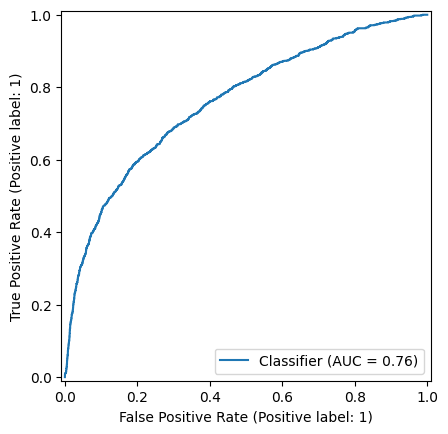

In [5]:
# Define the model
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model in batches
num_epochs = 125
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Print average loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate the model
model.eval()  # Set model to evaluation mode
y_pred_probs = []
y_true = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        y_pred_probs.extend(outputs.numpy())  # Store predictions
        y_true.extend(batch_y.numpy())  # Store true labels

# Convert predictions to NumPy array
y_pred_probs = np.array(y_pred_probs).flatten()
y_true = np.array(y_true).flatten()

# Compute accuracy
accuracy = ((y_pred_probs > 0.5) == y_true).mean()
print(f"Accuracy: {accuracy:.4f}")

# Compute ROC AUC score
roc_auc = roc_auc_score(y_true, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_true, y_pred_probs)

## **6. Use SHAP to explain Neural network predictions**

In [6]:
# Use existing NumPy arrays
X_train_np = X_train
X_test_np = X_test

# Reduce background dataset for SHAP (using 200 samples instead of full training set)
background = shap.kmeans(X_train_np, 200)


# Wrapper function for PyTorch model inference
def model_wrapper(data):
    """Model wrapper for SHAP."""
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model(data_tensor).detach().numpy()
        # Should be (n_samples, n_classes)

# Use KernelExplainer with reduced background
explainer = shap.KernelExplainer(model_wrapper, background)


# Explain only a small subset of the test set (e.g., 50 samples)
X_test_sample = X_test_np[:50]


# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

print("X_test_sample shape:", X_test_sample.shape)  # Should be (n_samples, n_features)
print("SHAP values shape:", np.array(shap_values).shape)  # Should match (n_samples, n_features)

# Remove extra dimension if shap_values is (50, 23, 1)
shap_values = np.array(shap_values)  # Convert to NumPy array
if shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)  # Remove last dimension

# Ensure correct shape
print("Updated SHAP values shape:", shap_values.shape)  # Should be (50, 23)


# Generate SHAP summary plot
# shap.summary_plot(shap_values, X_test_sample, feature_names=data.columns[1:-1])

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/50 [00:00<?, ?it/s]

X_test_sample shape: (50, 23)
SHAP values shape: (50, 23, 1)
Updated SHAP values shape: (50, 23)


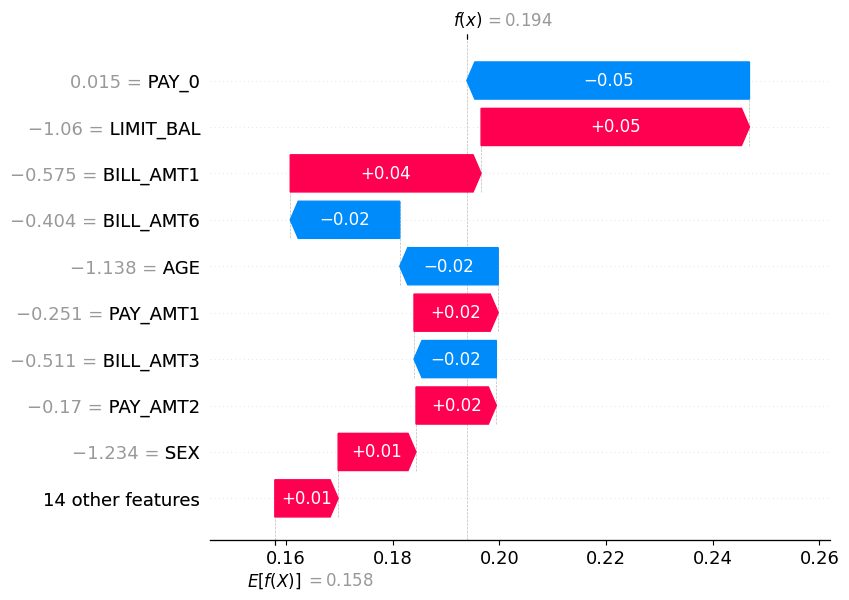

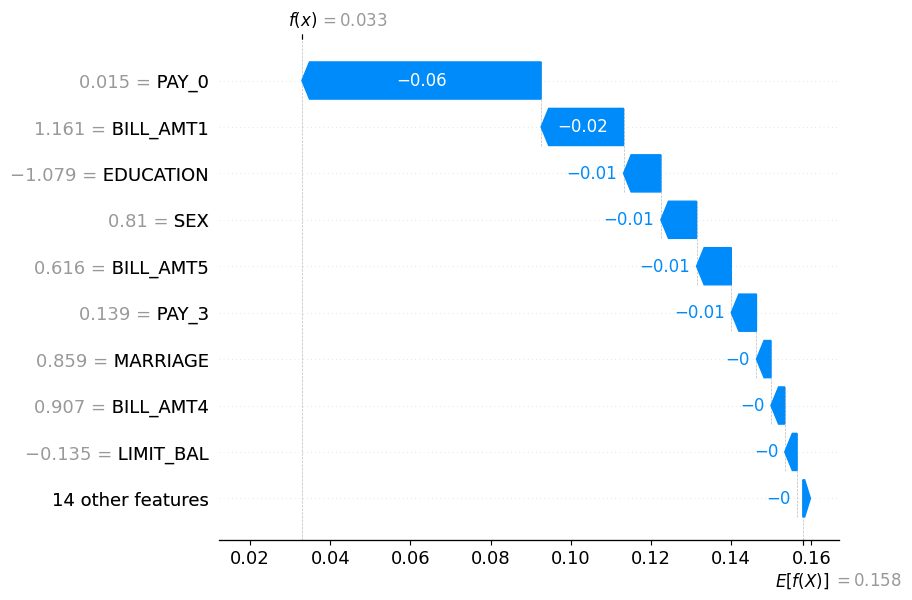

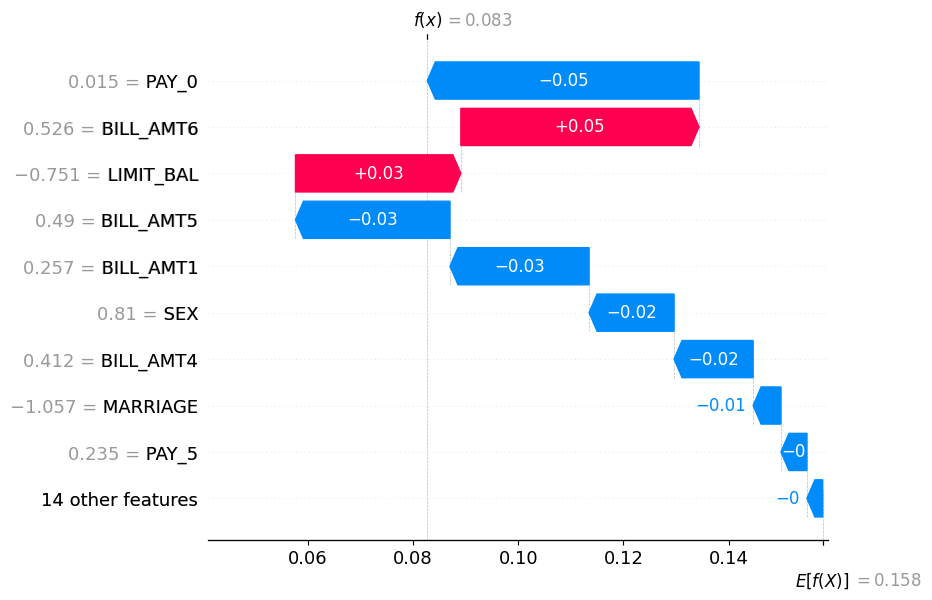

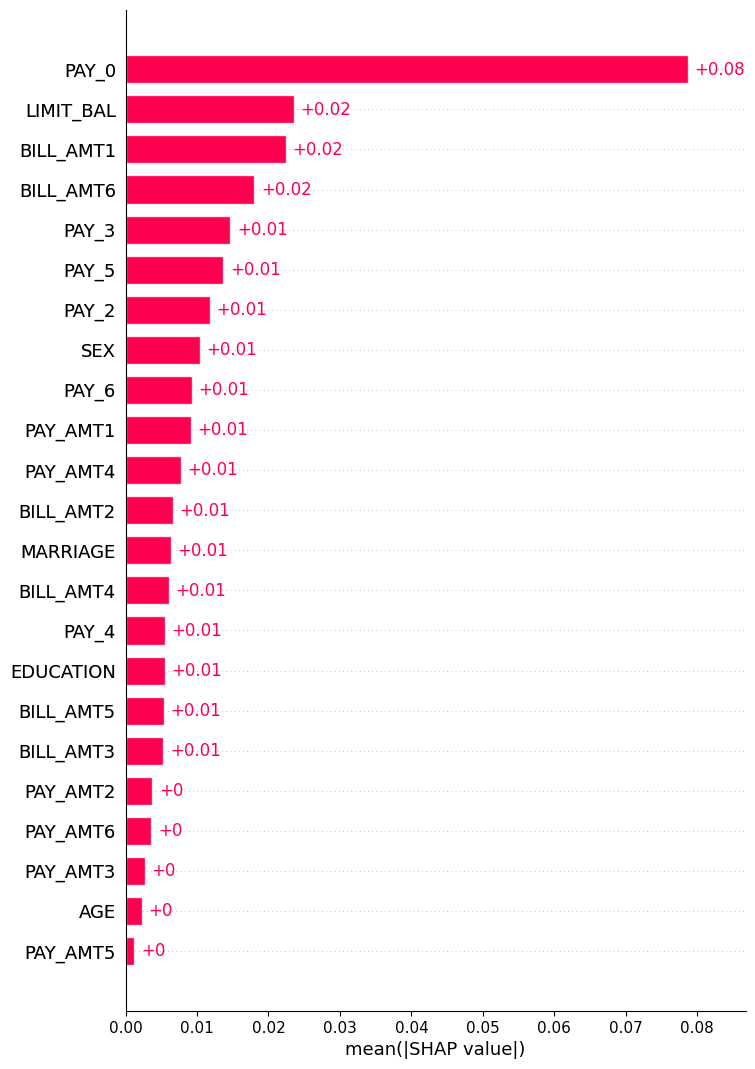

In [7]:
# Initialize SHAP JavaScript
shap.initjs()

# Create explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value[0],  # Use scalar
    data=X_test_sample,
    feature_names=list(data.columns[1:-1])
)

# Waterfall plots for first 3 samples
for i in range(3):
    shap.plots.waterfall(explanation[i])

# Global feature importance plot
shap.plots.bar(explanation, max_display=30)

# Reflection & Concept Check

#### 1. Thought Experiment

**How might correlated features affect SHAP interpretations?**

**Answer:**

KernelSHAP approximates Shapley values by sampling feature coalitions and implicitly assumes feature independence when marginalizing missing features.
If features are correlated (e.g., `BILL_AMT1–6`):

* Importance may be **distributed across correlated features**
* Attribution may appear diluted
* Removing one correlated feature may not change prediction much (since others substitute)

This can:

* Underestimate true causal importance
* Make rankings unstable
* Produce misleading interpretations

In financial datasets, repayment and bill history are strongly correlated, so SHAP values reflect predictive contribution under independence assumptions, not causal effect.

In [8]:
# Compute correlation matrix
X_train_df = pd.DataFrame(X_train, columns=data.columns[1:-1])
correlation_matrix = X_train_df.corr()
print(correlation_matrix)

           LIMIT_BAL       SEX  EDUCATION  MARRIAGE       AGE     PAY_0  \
LIMIT_BAL   1.000000  0.022468  -0.222694 -0.109410  0.149027 -0.268788   
SEX         0.022468  1.000000   0.008460 -0.030239 -0.095968 -0.061592   
EDUCATION  -0.222694  0.008460   1.000000 -0.139139  0.170392  0.105604   
MARRIAGE   -0.109410 -0.030239  -0.139139  1.000000 -0.413968  0.020772   
AGE         0.149027 -0.095968   0.170392 -0.413968  1.000000 -0.039049   
PAY_0      -0.268788 -0.061592   0.105604  0.020772 -0.039049  1.000000   
PAY_2      -0.297163 -0.072211   0.122386  0.027194 -0.048026  0.674819   
PAY_3      -0.285663 -0.067700   0.113294  0.035752 -0.053835  0.578488   
PAY_4      -0.268756 -0.064210   0.109408  0.035414 -0.050055  0.542034   
PAY_5      -0.248837 -0.058703   0.096191  0.043635 -0.056765  0.510700   
PAY_6      -0.235134 -0.052359   0.078335  0.040485 -0.051623  0.475909   
BILL_AMT1   0.283519 -0.035774   0.021361 -0.021807  0.055081  0.190892   
BILL_AMT2   0.277148 -0.0

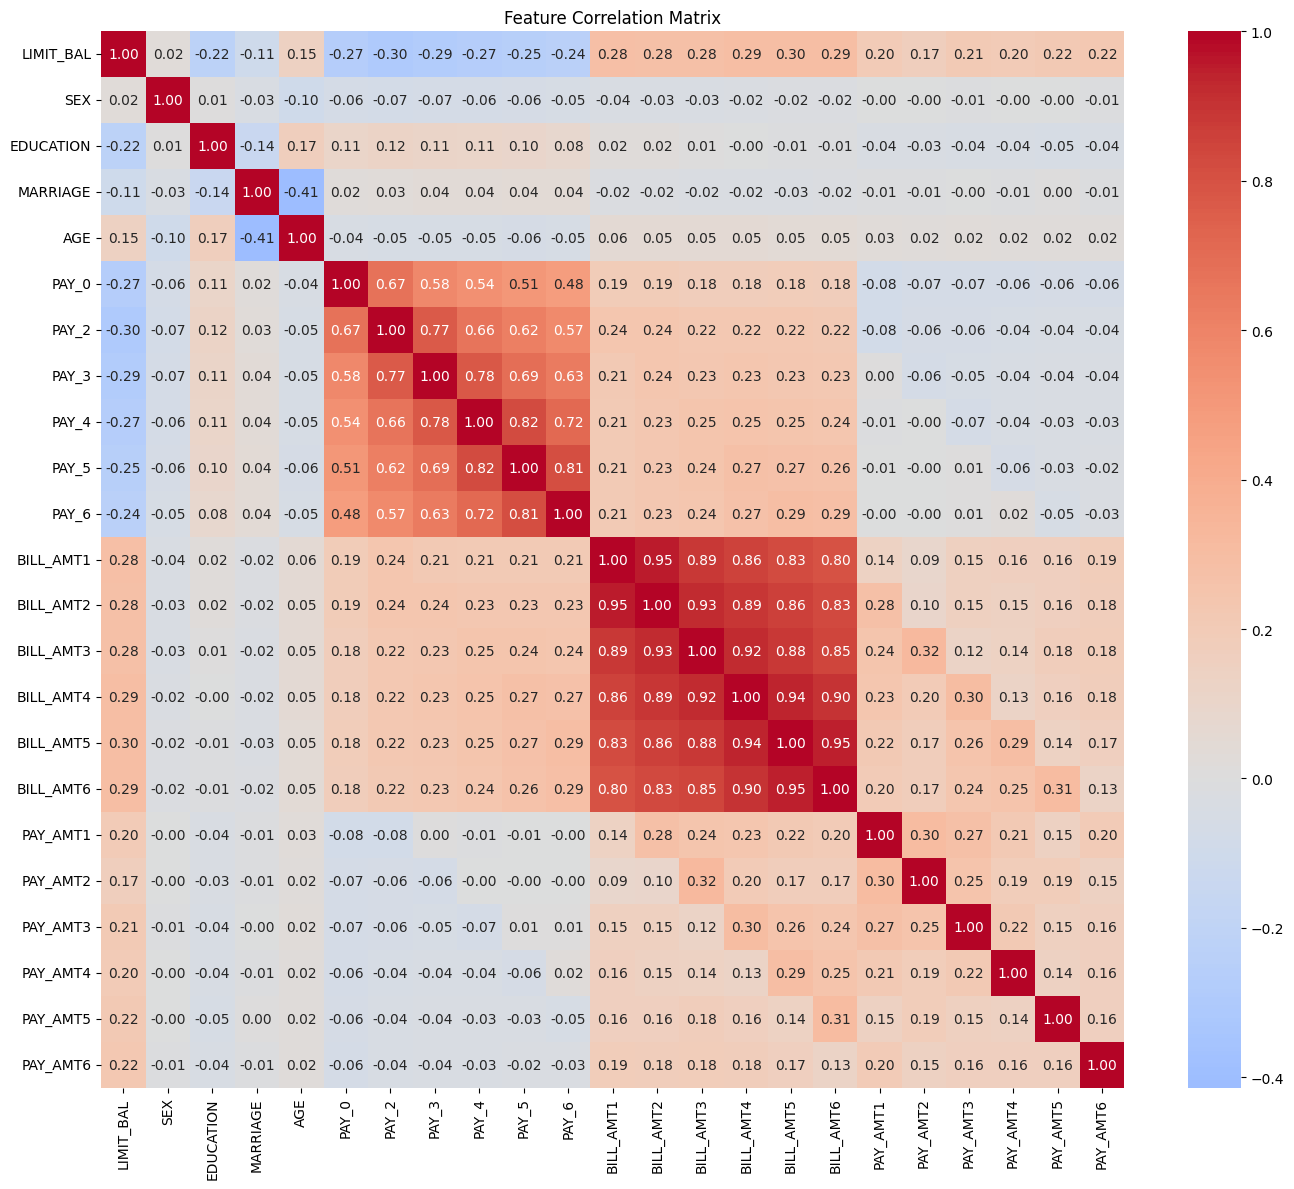

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create correlation heatmap with feature names
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
# Find pairs with correlation > 0.7
def find_high_correlations(corr_matrix, threshold=0.7):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs)

high_corr = find_high_correlations(correlation_matrix, threshold=0.7)
print(high_corr.sort_values('Correlation', ascending=False, key=abs))

    Feature 1  Feature 2  Correlation
5   BILL_AMT1  BILL_AMT2     0.951598
19  BILL_AMT5  BILL_AMT6     0.946754
17  BILL_AMT4  BILL_AMT5     0.938511
10  BILL_AMT2  BILL_AMT3     0.925135
14  BILL_AMT3  BILL_AMT4     0.918356
18  BILL_AMT4  BILL_AMT6     0.900838
11  BILL_AMT2  BILL_AMT4     0.890216
6   BILL_AMT1  BILL_AMT3     0.888002
15  BILL_AMT3  BILL_AMT5     0.878807
12  BILL_AMT2  BILL_AMT5     0.859068
7   BILL_AMT1  BILL_AMT4     0.855804
16  BILL_AMT3  BILL_AMT6     0.850489
13  BILL_AMT2  BILL_AMT6     0.830404
8   BILL_AMT1  BILL_AMT5     0.827622
2       PAY_4      PAY_5     0.820118
4       PAY_5      PAY_6     0.814612
9   BILL_AMT1  BILL_AMT6     0.800231
1       PAY_3      PAY_4     0.777305
0       PAY_2      PAY_3     0.768607
3       PAY_4      PAY_6     0.715312


In [11]:
# Create a drop list based on high correlations
features_to_drop = []

# Find highly correlated pairs and keep only one from each pair
for _, row in high_corr.iterrows():
    # Drop the second feature from each pair to avoid duplicates
    if row['Feature 2'] not in features_to_drop:
        features_to_drop.append(row['Feature 2'])

print("Features to drop:", features_to_drop)

# Get feature names
feature_names = list(data.columns[1:-1])
print(f"Original features: {len(feature_names)}")
print(f"Dropping {len(features_to_drop)} features")

# Get indices of features to drop
drop_indices = [i for i, col in enumerate(feature_names) if col in features_to_drop]

# Remove correlated features from training and test data
X_train_reduced = np.delete(X_train, drop_indices, axis=1)
X_test_reduced = np.delete(X_test, drop_indices, axis=1)
X_test_sample_reduced = np.delete(X_test_sample, drop_indices, axis=1)

# Get remaining feature names
remaining_features = [col for col in feature_names if col not in features_to_drop]

print(f"Reduced features: {len(remaining_features)}")
print("Remaining features:", remaining_features)

Features to drop: ['PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
Original features: 23
Dropping 9 features
Reduced features: 14
Remaining features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [29]:
# Retrain model with reduced features
model_reduced = nn.Sequential(
    nn.Linear(X_train_reduced.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model_reduced.parameters(), lr=0.001)

# Create datasets with reduced features
train_dataset_reduced = CreditDataset(X_train_reduced, y_train)
test_dataset_reduced = CreditDataset(X_test_reduced, y_test)

train_loader_reduced = DataLoader(train_dataset_reduced, batch_size=64, shuffle=True)
test_loader_reduced = DataLoader(test_dataset_reduced, batch_size=64, shuffle=False)

# Train the reduced model
num_epochs = 125
for epoch in range(num_epochs):
    model_reduced.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader_reduced:
        optimizer.zero_grad()
        outputs = model_reduced(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader_reduced)
        # print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate reduced model
model_reduced.eval()
y_pred_probs_reduced = []
with torch.no_grad():
    for batch_x, _ in test_loader_reduced:
        outputs = model_reduced(batch_x)
        y_pred_probs_reduced.extend(outputs.numpy())

y_pred_probs_reduced = np.array(y_pred_probs_reduced).flatten()
accuracy_reduced = ((y_pred_probs_reduced > 0.5) == y_test).mean()
roc_auc_reduced = roc_auc_score(y_test, y_pred_probs_reduced)
print(f"Reduced Model Accuracy: {accuracy_reduced:.4f}")
print(f"Reduced Model ROC AUC Score: {roc_auc_reduced:.4f}")

Reduced Model Accuracy: 0.8140
Reduced Model ROC AUC Score: 0.7651


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_1117/1182074343.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_reduced, X_test_sample_reduced, feature_names=remaining_features)


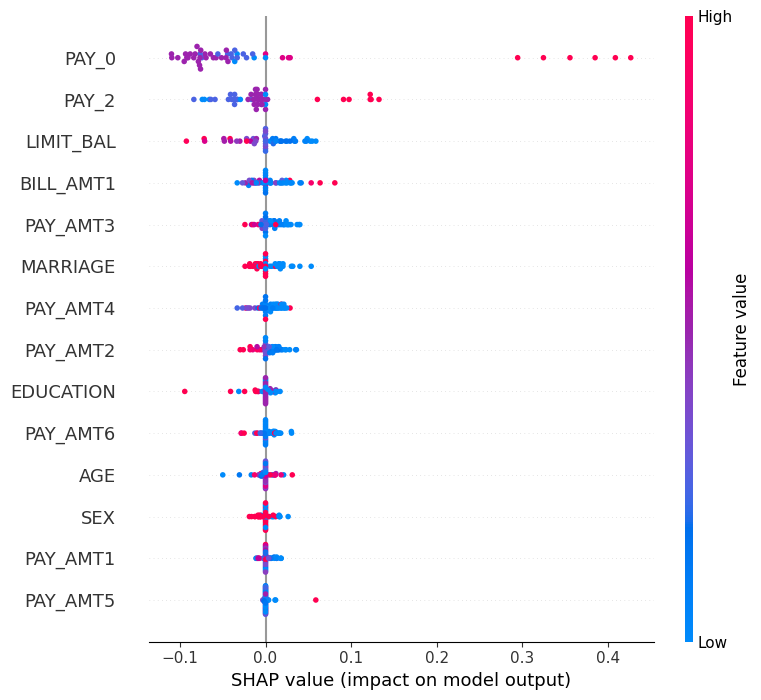

In [13]:
# Wrapper for reduced model
def model_wrapper_reduced(data):
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_reduced(data_tensor).detach().numpy()

# Create SHAP explainer with reduced model
explainer_reduced = shap.KernelExplainer(model_wrapper_reduced, shap.kmeans(X_train_reduced, 200))

# Compute SHAP values
shap_values_reduced = explainer_reduced.shap_values(X_test_sample_reduced)
shap_values_reduced = np.array(shap_values_reduced).squeeze(-1) if np.array(shap_values_reduced).shape[-1] == 1 else shap_values_reduced

# Summary plot
shap.summary_plot(shap_values_reduced, X_test_sample_reduced, feature_names=remaining_features)

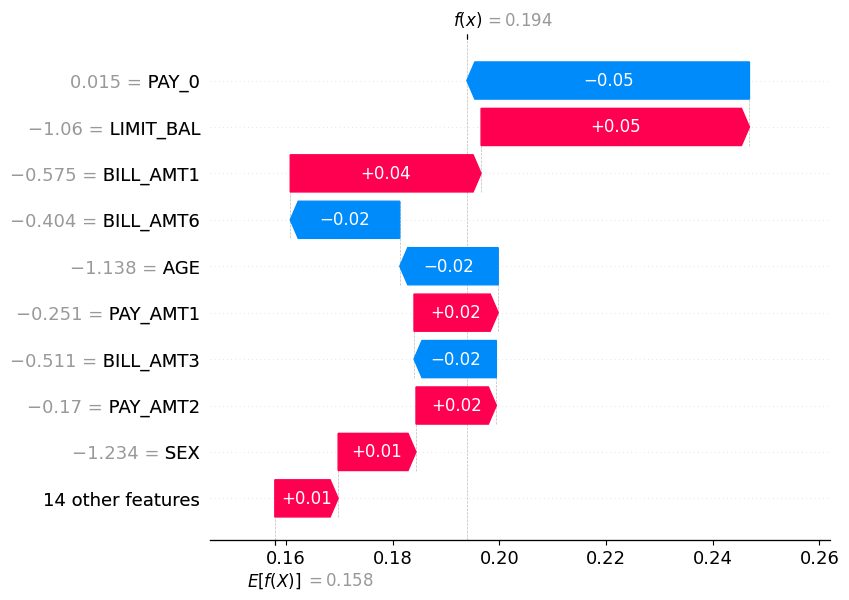

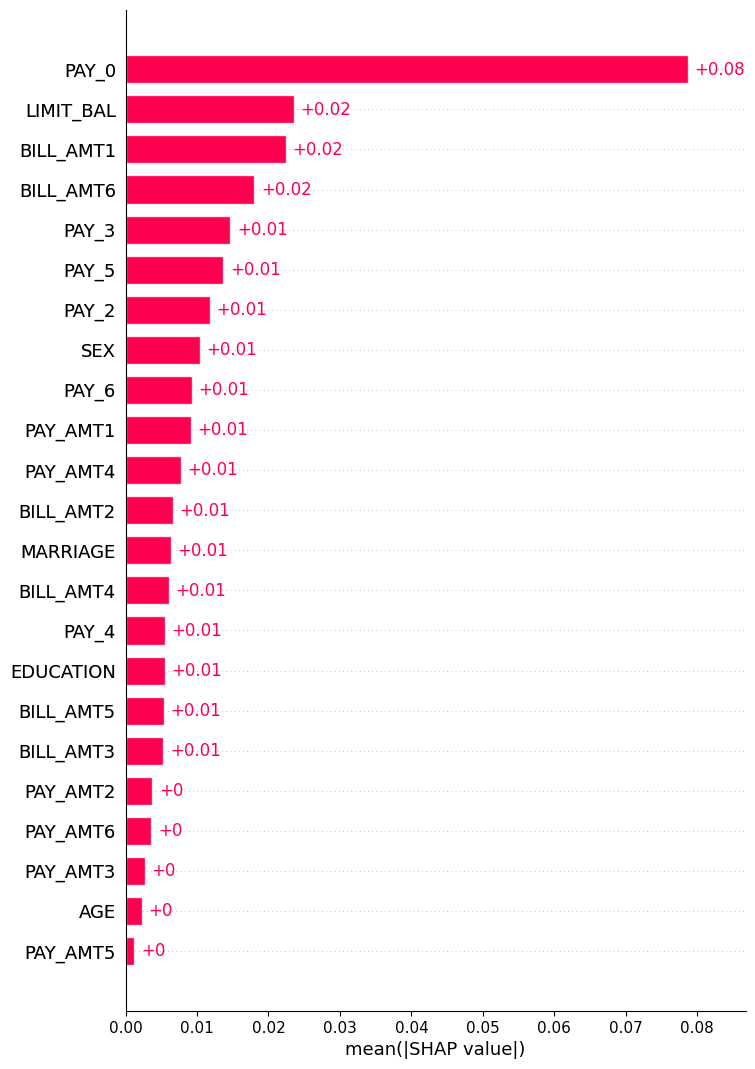

In [14]:
# Create explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value[0],  # Use scalar
    data=X_test_sample,
    feature_names=list(data.columns[1:-1])
)

shap.plots.waterfall(explanation[0])

shap.plots.bar(explanation, max_display=30)

#### 2️. Challenge

**If you removed repayment features (`PAY_*`), what would happen to SHAP importance rankings?**

**Answer:**

Likely outcomes:

* `BILL_AMT*` and `LIMIT_BAL` would become more important.
* Demographic features might slightly increase in relative importance.
* Overall model performance (ROC AUC) would drop.

Reason:

Repayment history is the strongest predictive signal of default.
Without it, the model must rely on weaker proxies (bill amounts, credit limit).

This tests whether the model is:

* Truly learning risk patterns
* Or heavily dependent on short-term delinquency signals

In [ ]:
# Identify PAY_* features to remove
pay_features = [col for col in remaining_features if col.startswith('PAY_')]
print(f"PAY_* features to remove: {pay_features}")

# Get indices of PAY_* features
pay_indices = [i for i, col in enumerate(remaining_features) if col.startswith('PAY_')]

# Remove PAY_* features from reduced datasets
X_train_reduced_no_pay = np.delete(X_train_reduced, pay_indices, axis=1)
X_test_reduced_no_pay = np.delete(X_test_reduced, pay_indices, axis=1)
X_test_sample_reduced_no_pay = np.delete(X_test_sample_reduced, pay_indices, axis=1)

# Update remaining features list
remaining_features_no_pay = [col for col in remaining_features if not col.startswith('PAY_')]

print(f"\nFeatures removed: {len(remaining_features) - len(remaining_features_no_pay)}")
print(f"Original reduced features: {len(remaining_features)}")
print(f"After removing PAY_*: {len(remaining_features_no_pay)}")
print(f"Remaining features: {remaining_features_no_pay}")

# Check shapes
print(f"\nX_train_reduced_no_pay shape: {X_train_reduced_no_pay.shape}")
print(f"X_test_reduced_no_pay shape: {X_test_reduced_no_pay.shape}")
print(f"X_test_sample_reduced_no_pay shape: {X_test_sample_reduced_no_pay.shape}")

PAY_* features to remove: ['PAY_0', 'PAY_2', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Features removed: 8
Original reduced features: 14
After removing PAY_*: 6
Remaining features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'BILL_AMT1']

X_train_reduced_no_pay shape: (24000, 6)
X_test_reduced_no_pay shape: (6000, 6)
X_test_sample_reduced_no_pay shape: (50, 6)


In [ ]:
# Retrain model without PAY_* features
model_no_pay = nn.Sequential(
    nn.Linear(X_train_reduced_no_pay.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Train
criterion = nn.BCELoss()
optimizer = optim.Adam(model_no_pay.parameters(), lr=0.001)

train_dataset_no_pay = CreditDataset(X_train_reduced_no_pay, y_train)
test_dataset_no_pay = CreditDataset(X_test_reduced_no_pay, y_test)
train_loader_no_pay = DataLoader(train_dataset_no_pay, batch_size=64, shuffle=True)
test_loader_no_pay = DataLoader(test_dataset_no_pay, batch_size=64, shuffle=False)

num_epochs = 125
for epoch in range(num_epochs):
    model_no_pay.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader_no_pay:
        optimizer.zero_grad()
        outputs = model_no_pay(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader_no_pay)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate
model_no_pay.eval()
y_pred_no_pay = []
with torch.no_grad():
    for batch_x, _ in test_loader_no_pay:
        outputs = model_no_pay(batch_x)
        y_pred_no_pay.extend(outputs.numpy())

y_pred_no_pay = np.array(y_pred_no_pay).flatten()
accuracy_no_pay = ((y_pred_no_pay > 0.5) == y_test).mean()
roc_auc_no_pay = roc_auc_score(y_test, y_pred_no_pay)
print(f"\nModel without PAY_* Accuracy: {accuracy_no_pay:.4f}")
print(f"Model without PAY_* ROC AUC Score: {roc_auc_no_pay:.4f}")

# Compare with original model
print(f"\nOriginal Model ROC AUC: {roc_auc:.4f}")
print(f"Model without PAY_* ROC AUC: {roc_auc_no_pay:.4f}")
print(f"Difference: {roc_auc - roc_auc_no_pay:.4f}")

Epoch [10/125], Loss: 0.5110
Epoch [20/125], Loss: 0.5078
Epoch [30/125], Loss: 0.5062
Epoch [40/125], Loss: 0.5051
Epoch [50/125], Loss: 0.5038
Epoch [60/125], Loss: 0.5037
Epoch [70/125], Loss: 0.5034
Epoch [80/125], Loss: 0.5029
Epoch [90/125], Loss: 0.5019
Epoch [100/125], Loss: 0.5018
Epoch [110/125], Loss: 0.5028
Epoch [120/125], Loss: 0.5017

Model without PAY_* Accuracy: 0.7810
Model without PAY_* ROC AUC Score: 0.6361

Original Model ROC AUC: 0.7603
Model without PAY_* ROC AUC: 0.6361
Difference: 0.1242



=== SHAP Waterfall Plots (without PAY_*) ===


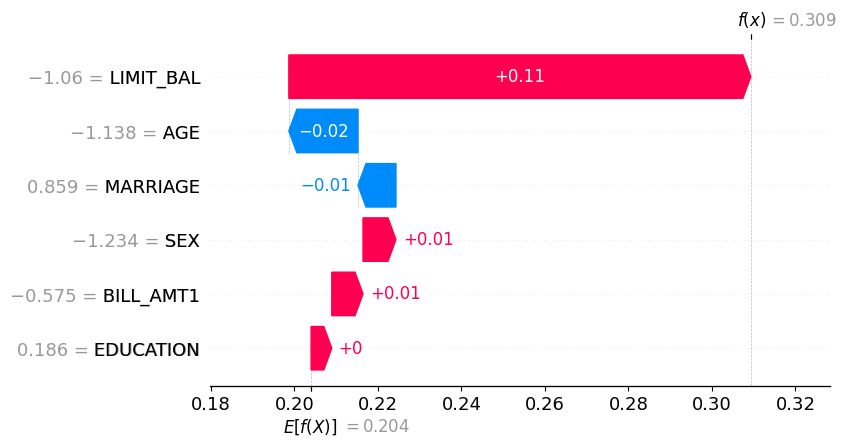


=== SHAP Global Plots (without PAY_*) ===


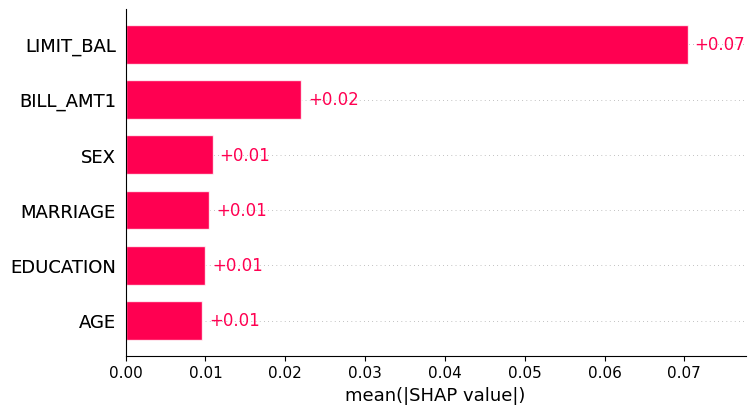

In [ ]:
# Create SHAP explainer for model without PAY_* features
def model_wrapper_no_pay(data):
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_no_pay(data_tensor).detach().numpy()

# Create SHAP explainer
explainer_no_pay = shap.KernelExplainer(model_wrapper_no_pay, shap.kmeans(X_train_reduced_no_pay, 200))

# Compute SHAP values for test sample
shap_values_no_pay = explainer_no_pay.shap_values(X_test_sample_reduced_no_pay)

# Process SHAP values
shap_values_no_pay = np.array(shap_values_no_pay)
if shap_values_no_pay.shape[-1] == 1:
    shap_values_no_pay = shap_values_no_pay.squeeze(-1)

print("SHAP values shape:", shap_values_no_pay.shape)

# Initialize SHAP for interactive plots
shap.initjs()

# Generate summary plot (bar)
print("\n=== SHAP Summary Plot (without PAY_*) ===")
shap.summary_plot(shap_values_no_pay, X_test_sample_reduced_no_pay, feature_names=remaining_features_no_pay)
plt.show()


# Generate waterfall and global plots
explanation = shap.Explanation(
    values=shap_values_no_pay,
    base_values=explainer_no_pay.expected_value[0],  # Use scalar
    data=X_test_sample_reduced_no_pay,
    feature_names=remaining_features_no_pay
)

print("\n=== SHAP Waterfall Plots (without PAY_*) ===")
shap.plots.waterfall(explanation[0])

print("\n=== SHAP Global Plots (without PAY_*) ===")
shap.plots.bar(explanation, max_display=30)

#### 3️. Thought Experiment

**If background size is reduced from 200 → 20, what changes?**

**Answer:**

* Runtime decreases significantly.
* Variance of SHAP values increases.
* Summary plot may become noisier.
* Individual explanations become less stable.

Because SHAP approximates expectations over background data, fewer background samples → less accurate estimation of the expected value.

In [28]:
# Wrapper for reduced model
def model_wrapper_reduced(data):
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_reduced(data_tensor).detach().numpy()

# Create SHAP explainer with reduced model
explainer_reduced = shap.KernelExplainer(model_wrapper_reduced, shap.kmeans(X_train_reduced, 20)) # change to 20

# Compute SHAP values
shap_values_reduced = explainer_reduced.shap_values(X_test_sample_reduced)
shap_values_reduced = np.array(shap_values_reduced).squeeze(-1) if np.array(shap_values_reduced).shape[-1] == 1 else shap_values_reduced

# # Summary plot
# shap.summary_plot(shap_values_reduced, X_test_sample_reduced, feature_names=remaining_features)

# # Create explanation object
# explanation = shap.Explanation(
#     values=shap_values,
#     base_values=explainer.expected_value[0],  # Use scalar
#     data=X_test_sample,
#     feature_names=list(data.columns[1:-1])
# )

# shap.plots.waterfall(explanation[0])

# shap.plots.bar(explanation, max_display=30)

  0%|          | 0/50 [00:00<?, ?it/s]

#### 4️. Challenge

**If SHAP value for `PAY_0` is +0.15, what does that mean numerically?**

**Answer:**

SHAP decomposes:

$\text{Model output} = \text{expected value} + \sum_i \phi_i$

If:

* Expected prediction = 0.32 (baseline probability)
* SHAP(PAY_0) = +0.15

Then:

PAY_0 contributes +0.15 to the predicted probability relative to the expected prediction (baseline), holding other feature contributions additive.

So prediction becomes:

$0.32 + 0.15 + \text{(other feature contributions)}$

It is not a “risk score” — it is an additive contribution relative to baseline.

In [37]:
import numpy as np
from scipy.special import expit  # Sigmoid function

def output_shap_probabilities(base_value, shap_values, sample_ids=None):
    """
    Output predicted probabilities from SHAP values.
    
    Args:
        base_value: Base expected value from explainer
        shap_values: Array of SHAP values (n_samples, n_features)
        sample_ids: Optional sample identifiers
    
    Returns:
        Dictionary with probabilities and predictions
    """
    n_samples = shap_values.shape[0]
    
    if sample_ids is None:
        sample_ids = np.arange(n_samples)
    
    # Sum SHAP values across features for each sample
    shap_sums = np.sum(shap_values, axis=1)
    
    # Convert to probability: sigmoid(base_value + sum(SHAP))
    log_odds = base_value + shap_sums
    probabilities = expit(log_odds)
    
    # Binary predictions
    predictions = (probabilities > 0.5).astype(int)
    
    # Create results dictionary
    results = {
        'sample_id': sample_ids,
        'base_value': base_value,
        'shap_sum': shap_sums,
        'log_odds': log_odds,
        'probability': probabilities,
        'prediction': predictions,
        'risk_level': ['HIGH' if p > 0.7 else 'MEDIUM' if p > 0.4 else 'LOW' for p in probabilities]
    }
    
    return results


def print_probability_summary(results):
    """Print a formatted summary of probabilities."""
    print("\n" + "=" * 80)
    print("SHAP VALUES CONVERTED TO PROBABILITIES")
    print("=" * 80)
    print(f"\nBase Value (Expected Log-Odds): {results['base_value']:.4f}\n")
    print(f"{'Sample':<10} {'SHAP Sum':<12} {'Log-Odds':<12} {'Probability':<12} {'Pred':<6} {'Risk':<8}")
    print("-" * 80)
    
    for i in range(len(results['sample_id'])):
        print(f"{results['sample_id'][i]:<10} "
              f"{results['shap_sum'][i]:>11.4f} "
              f"{results['log_odds'][i]:>11.4f} "
              f"{results['probability'][i]:>11.4f} "
              f"{results['prediction'][i]:>5} "
              f"{results['risk_level'][i]:<8}")
    
    print("-" * 80)
    print(f"\nSummary Statistics:")
    print(f"  Mean Probability:   {np.mean(results['probability']):.4f}")
    print(f"  Median Probability: {np.median(results['probability']):.4f}")
    print(f"  Min - Max:          {np.min(results['probability']):.4f} - {np.max(results['probability']):.4f}")
    print(f"  High Risk (>0.7):   {np.sum(np.array(results['risk_level']) == 'HIGH')} samples")
    print(f"  Medium Risk:        {np.sum(np.array(results['risk_level']) == 'MEDIUM')} samples")
    print(f"  Low Risk:           {np.sum(np.array(results['risk_level']) == 'LOW')} samples")
    print("=" * 80 + "\n")

In [40]:
# # Wrapper for reduced model
# def model_wrapper_reduced(data):
#     with torch.no_grad():
#         data_tensor = torch.tensor(data, dtype=torch.float32)
#         return model_reduced(data_tensor).detach().numpy()

# # Create SHAP explainer with reduced model
# explainer_reduced = shap.KernelExplainer(model_wrapper_reduced, shap.kmeans(X_train_reduced, 200))

# # Compute SHAP values
# shap_values_reduced = explainer_reduced.shap_values(X_test_sample_reduced)
# shap_values_reduced = np.array(shap_values_reduced).squeeze(-1) if np.array(shap_values_reduced).shape[-1] == 1 else shap_values_reduced

results = output_shap_probabilities(
    base_value=explainer_reduced.expected_value[0],
    shap_values=shap_values_reduced
)

# Print formatted output
print_probability_summary(results)

# Or access individual probabilities
print(f"Probabilities: {results['probability']}")


SHAP VALUES CONVERTED TO PROBABILITIES

Base Value (Expected Log-Odds): 0.2070

Sample     SHAP Sum     Log-Odds     Probability  Pred   Risk    
--------------------------------------------------------------------------------
0               0.0562      0.2632      0.5654     1 MEDIUM  
1              -0.1354      0.0716      0.5179     1 MEDIUM  
2              -0.0979      0.1091      0.5273     1 MEDIUM  
3              -0.1475      0.0595      0.5149     1 MEDIUM  
4              -0.0194      0.1876      0.5468     1 MEDIUM  
5              -0.0518      0.1552      0.5387     1 MEDIUM  
6               0.5041      0.7111      0.6706     1 MEDIUM  
7               0.0829      0.2900      0.5720     1 MEDIUM  
8              -0.1962      0.0108      0.5027     1 MEDIUM  
9              -0.0495      0.1576      0.5393     1 MEDIUM  
10              0.5486      0.7556      0.6804     1 MEDIUM  
11             -0.0900      0.1170      0.5292     1 MEDIUM  
12             -0.0181      

#### 5️. Thought Experiment

**If you removed the sigmoid layer and computed SHAP on logits instead, what changes?**

**Answer:**

* SHAP values become additive in log-odds space (which is linear before the sigmoid transformation).
* Interpretations become more linear and stable.
* Contributions no longer bounded between 0 and 1.

Explaining logits is often mathematically cleaner because:

$\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$

Additive decompositions are more natural before nonlinear squashing.

THOUGHT EXPERIMENT 5: SHAP on Logits (Removing Sigmoid Layer)

model_reduced structure:
Sequential(
  (0): Linear(in_features=14, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=32, out_features=1, bias=True)
  (6): Sigmoid()
)

Model layers breakdown:
  [0] Linear(in_features=14, out_features=64, bias=True)
  [1] ReLU()
  [2] Linear(in_features=64, out_features=32, bias=True)
  [3] ReLU()
  [4] Dropout(p=0.3, inplace=False)
  [5] Linear(in_features=32, out_features=1, bias=True)
  [6] Sigmoid()

1. Creating SHAP explainers...
   ✓ Explainers created

2. Computing SHAP values...


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

   ✓ SHAP values computed

3. Output Comparison (First 5 Samples):
Sample   Logits          Probability     SHAP Sum (Logits)    SHAP Sum (Probs)    
   --------------------------------------------------------------------------------
   0               -1.0295         0.2632              0.9252              0.0780
   1               -2.5620         0.0716             -0.6072             -0.1136
   2               -2.0998         0.1091             -0.1451             -0.0761
   3               -2.7606         0.0595             -0.8058             -0.1257
   4               -1.4656         0.1876              0.4891              0.0024

4. Key Differences Between Logits and Probabilities:

   A. RANGE OF VALUES:
      Logits SHAP range:        [-1.9005, 2.6348]
      Probabilities SHAP range: [-0.1245, 0.4722]
      → Logit values are UNBOUNDED, probabilities are constrained [0,1]

   B. ADDITIVITY CHECK:
      Base value (logits):       -1.9547
      Base value (probabilities): 0.1852

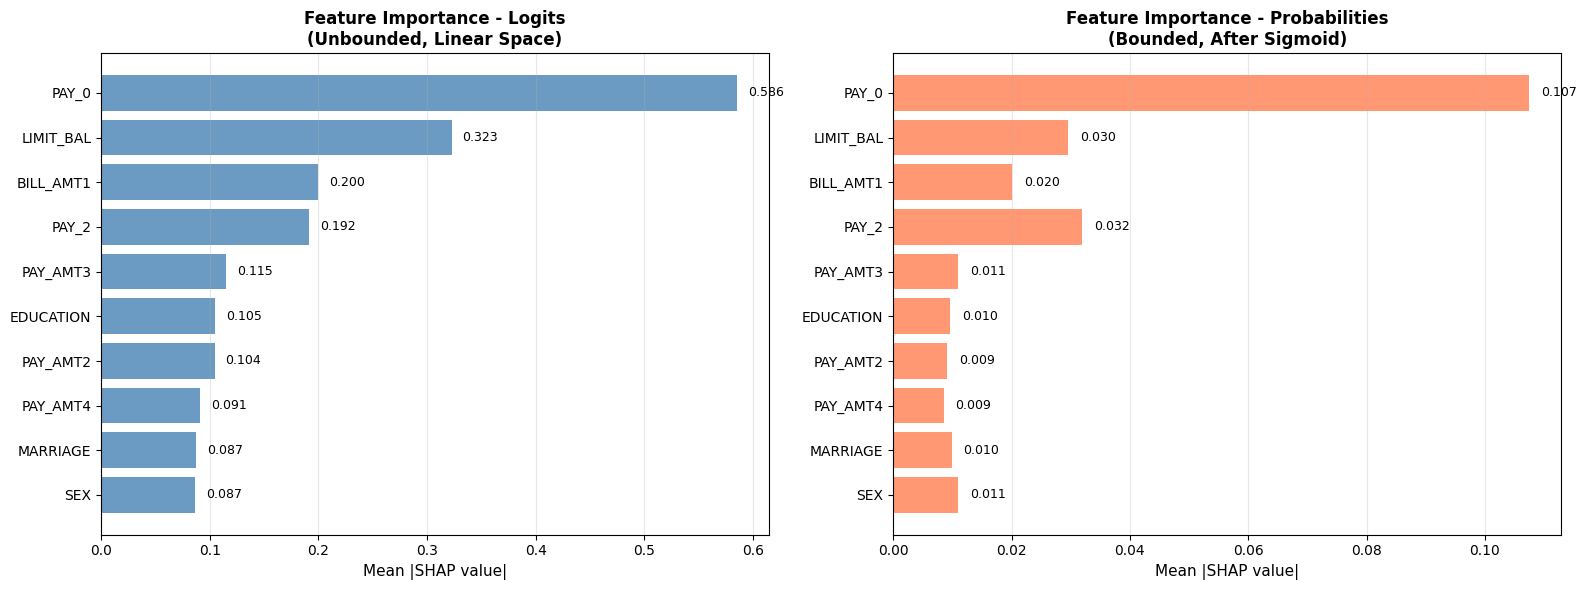

   ✓ Comparison plot saved


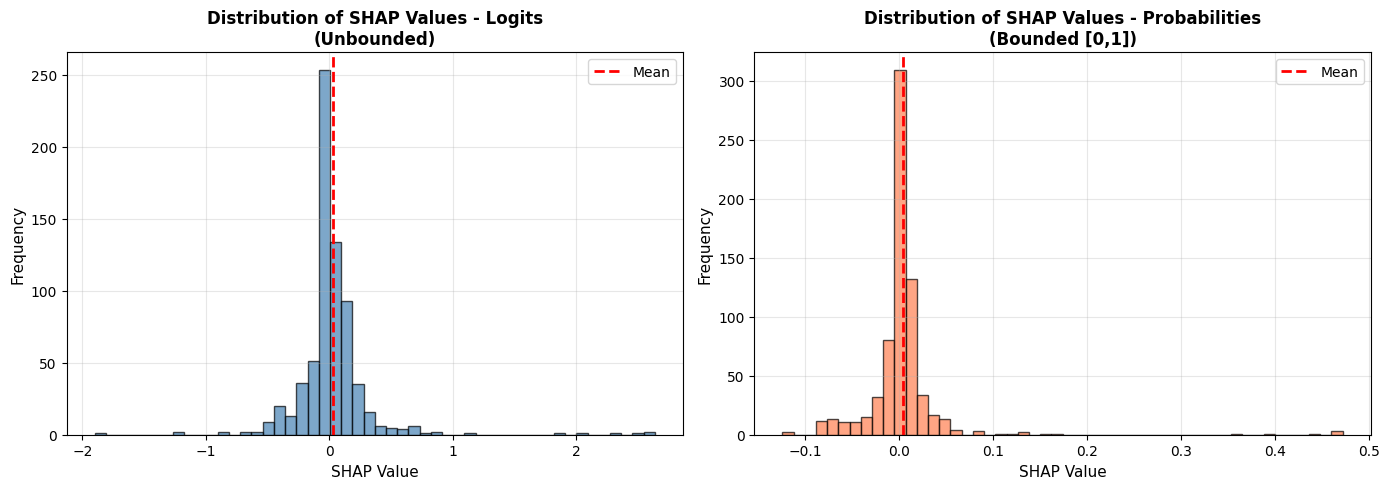

   ✓ Distribution plot saved

SUMMARY: Why SHAP on Logits is Mathematically Superior

MODEL STRUCTURE USED:
├─ [0] Linear(n_features, 64)
├─ [1] ReLU()
├─ [2] Linear(64, 32)
├─ [3] ReLU()
├─ [4] Dropout(0.3)
├─ [5] Linear(32, 1)  ← LOGITS OUTPUT (stop here)
└─ [6] Sigmoid()      ← REMOVED for logits computation

KEY MATHEMATICAL DIFFERENCES:

1. ADDITIVITY (CRITICAL):
   ✓ Logits:       output = base + Σφᵢ  [EXACT in linear space]
   ✗ Probs:        sigmoid(base + Σφᵢ)  [Approximate due to nonlinearity]

2. VALUE RANGES:
   • Logits SHAP:  [-∞, +∞]  Unbounded, full expressiveness
   • Probs SHAP:   [0, 1]    Compressed, limited range

3. INTERPRETATION STABILITY:
   • Logits:       No saturation effects, stable contributions
   • Probs:        Sigmoid saturation can obscure importance

4. PRACTICAL BENEFITS:
   ✓ Cleaner mathematical decomposition
   ✓ More stable sensitivity analysis
   ✓ Better for feature interaction studies
   ✓ No artificial compression of values

5. WHEN TO USE W

In [41]:
# ============================================================================
# SHAP on Logits (without sigmoid layer)
# Using model_reduced structure as template
# ============================================================================

import torch
import numpy as np
import shap
import matplotlib.pyplot as plt

print("=" * 80)
print("THOUGHT EXPERIMENT 5: SHAP on Logits (Removing Sigmoid Layer)")
print("=" * 80)

# ============================================================================
# Step 1: Model structure reference
# ============================================================================

print("\nmodel_reduced structure:")
print(model_reduced)

print("\nModel layers breakdown:")
for i, layer in enumerate(model_reduced):
    print(f"  [{i}] {layer}")

# ============================================================================
# Step 2: Create model wrapper that outputs logits
# ============================================================================

def model_wrapper_logits(data):
    """
    Outputs logits by stopping before sigmoid (layer 6).
    Structure: [0-5] layers (exclude Sigmoid at [6])
    """
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        
        # Forward through layers 0-5 (all except Sigmoid)
        x = data_tensor
        for i in range(6):  # 0 to 5 (excludes Sigmoid at index 6)
            x = model_reduced[i](x)
        
        return x.detach().numpy()


def model_wrapper_probabilities(data):
    """
    Outputs probabilities using full model with sigmoid.
    """
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_reduced(data_tensor).detach().numpy()


# ============================================================================
# Step 3: Create SHAP explainers
# ============================================================================

print("\n1. Creating SHAP explainers...")

background_data = shap.kmeans(X_train_reduced, 100)

explainer_logits = shap.KernelExplainer(model_wrapper_logits, background_data)
explainer_probs = shap.KernelExplainer(model_wrapper_probabilities, background_data)

print("   ✓ Explainers created")

# ============================================================================
# Step 4: Compute SHAP values
# ============================================================================

print("\n2. Computing SHAP values...")

shap_values_logits = explainer_logits.shap_values(X_test_sample_reduced)
shap_values_logits = np.array(shap_values_logits).squeeze()

shap_values_probs = explainer_probs.shap_values(X_test_sample_reduced)
shap_values_probs = np.array(shap_values_probs).squeeze()

print("   ✓ SHAP values computed")

# ============================================================================
# Step 5: Output comparison
# ============================================================================

print("\n3. Output Comparison (First 5 Samples):")
print("   " + "=" * 80)

logits_output = model_wrapper_logits(X_test_sample_reduced[:5])
probs_output = model_wrapper_probabilities(X_test_sample_reduced[:5])

print(f"{'Sample':<8} {'Logits':<15} {'Probability':<15} {'SHAP Sum (Logits)':<20} {'SHAP Sum (Probs)':<20}")
print("   " + "-" * 80)

for i in range(5):
    logit_val = logits_output[i, 0]
    prob_val = probs_output[i, 0]
    shap_sum_logits = np.sum(shap_values_logits[i])
    shap_sum_probs = np.sum(shap_values_probs[i])
    
    print(f"   {i:<8} {logit_val:>14.4f} {prob_val:>14.4f} {shap_sum_logits:>19.4f} {shap_sum_probs:>19.4f}")

print("   " + "=" * 80)

# ============================================================================
# Step 6: Key differences analysis
# ============================================================================

print("\n4. Key Differences Between Logits and Probabilities:")
print("   " + "=" * 80)

print("\n   A. RANGE OF VALUES:")
print(f"      Logits SHAP range:        [{np.min(shap_values_logits):.4f}, {np.max(shap_values_logits):.4f}]")
print(f"      Probabilities SHAP range: [{np.min(shap_values_probs):.4f}, {np.max(shap_values_probs):.4f}]")
print(f"      → Logit values are UNBOUNDED, probabilities are constrained [0,1]")

print("\n   B. ADDITIVITY CHECK:")
print(f"      Base value (logits):       {explainer_logits.expected_value[0]:.4f}")
print(f"      Base value (probabilities): {explainer_probs.expected_value[0]:.4f}")

# Verify additivity for sample 0
sample_idx = 0
logit_reconstruction = explainer_logits.expected_value[0] + np.sum(shap_values_logits[sample_idx])
actual_logit = logits_output[sample_idx, 0]

print(f"\n      Sample {sample_idx} (Logits - Perfect Linear Decomposition):")
print(f"        Base value + SHAP sum = {explainer_logits.expected_value[0]:.4f} + {np.sum(shap_values_logits[sample_idx]):.4f}")
print(f"                              = {logit_reconstruction:.4f}")
print(f"        Actual logit output   = {actual_logit:.4f}")
print(f"        Reconstruction error  = {abs(logit_reconstruction - actual_logit):.8f}")
print(f"      ✓ PERFECT additivity in log-odds space (linear before sigmoid)")

print("\n   C. FEATURE CONTRIBUTION BOUNDS:")
print(f"      Logits (max |SHAP|):       {np.max(np.abs(shap_values_logits)):.4f} (unbounded)")
print(f"      Probabilities (max |SHAP|): {np.max(np.abs(shap_values_probs)):.4f} (bounded by 0-1)")

print("   " + "=" * 80)

# ============================================================================
# Step 7: Visualization - Feature Importance Comparison
# ============================================================================

print("\n5. Generating comparison plots...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
feature_importance_logits = np.abs(shap_values_logits).mean(axis=0)
feature_importance_probs = np.abs(shap_values_probs).mean(axis=0)

# Top 10 features by logits importance
sort_idx = np.argsort(feature_importance_logits)[::-1][:10]
feature_names_sorted = [remaining_features[i] for i in sort_idx]

# Plot 1: Logits
ax1 = axes[0]
x_pos = np.arange(len(sort_idx))
bars1 = ax1.barh(x_pos, feature_importance_logits[sort_idx], alpha=0.8, color='steelblue')
ax1.set_yticks(x_pos)
ax1.set_yticklabels(feature_names_sorted, fontsize=10)
ax1.set_xlabel('Mean |SHAP value|', fontsize=11)
ax1.set_title('Feature Importance - Logits\n(Unbounded, Linear Space)', 
              fontweight='bold', fontsize=12)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, v) in enumerate(zip(sort_idx, feature_importance_logits[sort_idx])):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 2: Probabilities
ax2 = axes[1]
bars2 = ax2.barh(x_pos, feature_importance_probs[sort_idx], alpha=0.8, color='coral')
ax2.set_yticks(x_pos)
ax2.set_yticklabels(feature_names_sorted, fontsize=10)
ax2.set_xlabel('Mean |SHAP value|', fontsize=11)
ax2.set_title('Feature Importance - Probabilities\n(Bounded, After Sigmoid)', 
              fontweight='bold', fontsize=12)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, v) in enumerate(zip(sort_idx, feature_importance_probs[sort_idx])):
    ax2.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('shap_logits_vs_probs.png', dpi=100, bbox_inches='tight')
plt.show()

print("   ✓ Comparison plot saved")

# ============================================================================
# Step 8: Distribution comparison
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SHAP value distributions
ax1 = axes[0]
ax1.hist(shap_values_logits.flatten(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('SHAP Value', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of SHAP Values - Logits\n(Unbounded)', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)
ax1.axvline(np.mean(shap_values_logits), color='red', linestyle='--', linewidth=2, label='Mean')
ax1.legend()

ax2 = axes[1]
ax2.hist(shap_values_probs.flatten(), bins=50, alpha=0.7, color='coral', edgecolor='black')
ax2.set_xlabel('SHAP Value', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of SHAP Values - Probabilities\n(Bounded [0,1])', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3)
ax2.axvline(np.mean(shap_values_probs), color='red', linestyle='--', linewidth=2, label='Mean')
ax2.legend()

plt.tight_layout()
plt.savefig('shap_distribution_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("   ✓ Distribution plot saved")

# ============================================================================
# Step 9: Summary & Interpretation
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY: Why SHAP on Logits is Mathematically Superior")
print("=" * 80)

summary = """
MODEL STRUCTURE USED:
├─ [0] Linear(n_features, 64)
├─ [1] ReLU()
├─ [2] Linear(64, 32)
├─ [3] ReLU()
├─ [4] Dropout(0.3)
├─ [5] Linear(32, 1)  ← LOGITS OUTPUT (stop here)
└─ [6] Sigmoid()      ← REMOVED for logits computation

KEY MATHEMATICAL DIFFERENCES:

1. ADDITIVITY (CRITICAL):
   ✓ Logits:       output = base + Σφᵢ  [EXACT in linear space]
   ✗ Probs:        sigmoid(base + Σφᵢ)  [Approximate due to nonlinearity]

2. VALUE RANGES:
   • Logits SHAP:  [-∞, +∞]  Unbounded, full expressiveness
   • Probs SHAP:   [0, 1]    Compressed, limited range

3. INTERPRETATION STABILITY:
   • Logits:       No saturation effects, stable contributions
   • Probs:        Sigmoid saturation can obscure importance

4. PRACTICAL BENEFITS:
   ✓ Cleaner mathematical decomposition
   ✓ More stable sensitivity analysis
   ✓ Better for feature interaction studies
   ✓ No artificial compression of values

5. WHEN TO USE WHICH:
   • Model interpretation:     Use LOGITS ✓
   • Report to stakeholders:   Convert logits → probs for communication
   • Feature importance:       Compute on logits, present on probs scale
   • Debugging model:          Always use logits first

RECOMMENDATION:
Always compute SHAP on logits for neural networks with sigmoid output layers.
Convert to probability scale only for final reporting/visualization.
"""

print(summary)
print("=" * 80)

# Store results
results_summary = {
    'explainer_logits': explainer_logits,
    'explainer_probs': explainer_probs,
    'shap_values_logits': shap_values_logits,
    'shap_values_probs': shap_values_probs,
    'base_value_logits': explainer_logits.expected_value[0],
    'base_value_probs': explainer_probs.expected_value[0],
}

print("\n✓ Results stored in 'results_summary' dictionary")